# 1. Setup and Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Load Dataset Files


In [5]:
DATA_DIR = "../data/raw"

train = pd.read_csv(f"{DATA_DIR}/train.csv")
test = pd.read_csv(f"{DATA_DIR}/test.csv")
stores = pd.read_csv(f"{DATA_DIR}/stores.csv")
features = pd.read_csv(f"{DATA_DIR}/features.csv")

In [6]:
datasets = {
    "train": train,
    "test": test,
    "stores": stores,
    "features": features,
}

for name, df in datasets.items():
    print(f"{name}: {df.shape}")
    display(df.head())

train: (421570, 5)


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


test: (115064, 4)


,Store,Dept,Date,IsHoliday
0,1,1,2012-11-02,False
1,1,1,2012-11-09,False
2,1,1,2012-11-16,False
3,1,1,2012-11-23,True
4,1,1,2012-11-30,False


stores: (45, 3)


,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


features: (8190, 12)


,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


# 3. Basic File Overview


In [ ]:
# basic information about each dataset
for name, df in datasets.items():
    print("=" * 80)
    print(f"{name.upper()}")
    print("=" * 80)
    
    print("\nShape:")
    print(df.shape)
    
    print("\nColumns:")
    print(df.columns.tolist())
    
    print("\nData types:")
    print(df.dtypes)
    
    print("\nMissing values:")
    missing = df.isna().sum()
    missing_percent = (df.isna().mean() * 100).round(2)
    missing_table = pd.DataFrame({
        "missing_count": missing,
        "missing_percent": missing_percent
    })
    display(missing_table[missing_table["missing_count"] > 0])
    
    print("\nDuplicate rows:")
    print(df.duplicated().sum())
    
    print("\n")

TRAIN

Shape:
(421570, 5)

Columns:
['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday']

Data types:
Store             int64
Dept              int64
Date             object
Weekly_Sales    float64
IsHoliday          bool
dtype: object

Missing values:


,missing_count,missing_percent



Duplicate rows:
0


TEST

Shape:
(115064, 4)

Columns:
['Store', 'Dept', 'Date', 'IsHoliday']

Data types:
Store         int64
Dept          int64
Date         object
IsHoliday      bool
dtype: object

Missing values:


,missing_count,missing_percent



Duplicate rows:
0


STORES

Shape:
(45, 3)

Columns:
['Store', 'Type', 'Size']

Data types:
Store     int64
Type     object
Size      int64
dtype: object

Missing values:


,missing_count,missing_percent



Duplicate rows:
0


FEATURES

Shape:
(8190, 12)

Columns:
['Store', 'Date', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'IsHoliday']

Data types:
Store             int64
Date             object
Temperature     float64
Fuel_Price      float64
MarkDown1       float64
MarkDown2       float64
MarkDown3       float64
MarkDown4       float64
MarkDown5       float64
CPI             float64
Unemployment    float64
IsHoliday          bool
dtype: object

Missing values:


,missing_count,missing_percent
MarkDown1,4158,50.77
MarkDown2,5269,64.33
MarkDown3,4577,55.89
MarkDown4,4726,57.70
MarkDown5,4140,50.55
CPI,585,7.14
Unemployment,585,7.14



Duplicate rows:
0




markdown missing values probably need special handling later

# 4. Date Ranges and Forecasting Setup

In [ ]:
# convert date columns to datetime

train["Date"] = pd.to_datetime(train["Date"])
test["Date"] = pd.to_datetime(test["Date"])
features["Date"] = pd.to_datetime(features["Date"])

# date ranges
date_summary = pd.DataFrame({
    "dataset": ["train", "test", "features"],
    "min_date": [train["Date"].min(), test["Date"].min(), features["Date"].min()],
    "max_date": [train["Date"].max(), test["Date"].max(), features["Date"].max()],
    "unique_dates": [train["Date"].nunique(), test["Date"].nunique(), features["Date"].nunique()]
})

display(date_summary)

,dataset,min_date,max_date,unique_dates
0,train,2010-02-05,2012-10-26,143
1,test,2012-11-02,2013-07-26,39
2,features,2010-02-05,2013-07-26,182


In [10]:
# unique dates and spacing between weeks

for name, df in {"train": train, "test": test, "features": features}.items():
    unique_dates = pd.Series(sorted(df["Date"].unique()))
    date_diffs = unique_dates.diff().dropna().value_counts().sort_index()
    
    print("=" * 80)
    print(name.upper())
    print("=" * 80)
    print("Number of unique dates:", len(unique_dates))
    print("First 5 dates:")
    display(unique_dates.head())
    print("Last 5 dates:")
    display(unique_dates.tail())
    print("Date differences:")
    display(date_diffs)
    print("\n")

TRAIN
Number of unique dates: 143
First 5 dates:


0   2010-02-05
1   2010-02-12
2   2010-02-19
3   2010-02-26
4   2010-03-05
dtype: datetime64[ns]

Last 5 dates:


138   2012-09-28
139   2012-10-05
140   2012-10-12
141   2012-10-19
142   2012-10-26
dtype: datetime64[ns]

Date differences:


...

0   2010-02-05
1   2010-02-12
2   2010-02-19
3   2010-02-26
4   2010-03-05
dtype: datetime64[ns]

Last 5 dates:


177   2013-06-28
178   2013-07-05
179   2013-07-12
180   2013-07-19
181   2013-07-26
dtype: datetime64[ns]

Date differences:


7 days    181
Name: count, dtype: int64

The dataset is organized as regular weekly series. The training set contains 143 weekly dates from 2010-02-05 to 2012-10-26 while the test set contains the following 39 weekly dates from 2012-11-02 to 2013-07-26. The `features.csv` file covers the entire train and test period  143 + 39 = 182 weekly dates in total.

In [12]:
# basic forecasting setup

print("Train columns:", train.columns.tolist())
print("Test columns:", test.columns.tolist())

print("\nTarget column in train:")
print("Weekly_Sales" in train.columns)

print("\nTarget column in test:")
print("Weekly_Sales" in test.columns)

print("\nPrediction unit columns:")
print(["Store", "Dept", "Date"])

Train columns: ['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday']
Test columns: ['Store', 'Dept', 'Date', 'IsHoliday']

Target column in train:
True

Target column in test:
False

Prediction unit columns:
['Store', 'Dept', 'Date']


# 5. Store/Department Structure

In [13]:
train_key_duplicates = train.duplicated(subset=["Store", "Dept", "Date"]).sum()
test_key_duplicates = test.duplicated(subset=["Store", "Dept", "Date"]).sum()

print("Duplicate Store-Dept-Date rows in train:", train_key_duplicates)
print("Duplicate Store-Dept-Date rows in test:", test_key_duplicates)

Duplicate Store-Dept-Date rows in train: 0
Duplicate Store-Dept-Date rows in test: 0


In [14]:
# store, department and time series counts

n_stores_train = train["Store"].nunique()
n_depts_train = train["Dept"].nunique()
n_series_train = train[["Store", "Dept"]].drop_duplicates().shape[0]

n_stores_test = test["Store"].nunique()
n_depts_test = test["Dept"].nunique()
n_series_test = test[["Store", "Dept"]].drop_duplicates().shape[0]

summary = pd.DataFrame({
    "dataset": ["train", "test"],
    "unique_stores": [n_stores_train, n_stores_test],
    "unique_departments": [n_depts_train, n_depts_test],
    "unique_store_dept_series": [n_series_train, n_series_test],
    "rows": [len(train), len(test)],
    "unique_dates": [train["Date"].nunique(), test["Date"].nunique()]
})

display(summary)

,dataset,unique_stores,unique_departments,unique_store_dept_series,rows,unique_dates
0,train,45,81,3331,421570,143
1,test,45,81,3169,115064,39


In [ ]:
# check whether test contains unseen stores, departments or Store-Dept pairs

train_stores = set(train["Store"].unique())
test_stores = set(test["Store"].unique())

train_depts = set(train["Dept"].unique())
test_depts = set(test["Dept"].unique())

train_series = set(map(tuple, train[["Store", "Dept"]].drop_duplicates().values))
test_series = set(map(tuple, test[["Store", "Dept"]].drop_duplicates().values))

unseen_stores = test_stores - train_stores
unseen_depts = test_depts - train_depts
unseen_series = test_series - train_series

print("Unseen stores in test:", len(unseen_stores))
print("Unseen departments in test:", len(unseen_depts))
print("Unseen store-dept pairs in test:", len(unseen_series))

if len(unseen_series) > 0:
    print("\nExample unseen store-dept pairs:")
    print(list(unseen_series)[:10])

Unseen stores in test: 0
Unseen departments in test: 0
Unseen store-dept pairs in test: 11

Example unseen store-dept pairs:
[(np.int64(18), np.int64(43)), (np.int64(24), np.int64(43)), (np.int64(36), np.int64(30)), (np.int64(37), np.int64(29)), (np.int64(25), np.int64(99)), (np.int64(9), np.int64(99)), (np.int64(34), np.int64(39)), (np.int64(45), np.int64(39)), (np.int64(42), np.int64(30)), (np.int64(10), np.int64(99))]


for these 11 series, you cannot use exact historical features like store-dept level average sales, rolling means, lags and so on.

In [25]:
# num of observations per store-dept series in train and test

train_series_lengths = (
    train.groupby(["Store", "Dept"])
    .size()
    .reset_index(name="n_train_weeks")
)

test_series_lengths = (
    test.groupby(["Store", "Dept"])
    .size()
    .reset_index(name="n_test_weeks")
)

display(train_series_lengths["n_train_weeks"].describe())
display(test_series_lengths["n_test_weeks"].describe())

count    3331.000000
mean      126.559592
std        40.212763
min         1.000000
25%       143.000000
50%       143.000000
75%       143.000000
max       143.000000
Name: n_train_weeks, dtype: float64

count    3169.000000
mean       36.309246
std         8.417359
min         1.000000
25%        39.000000
50%        39.000000
75%        39.000000
max        39.000000
Name: n_test_weeks, dtype: float64

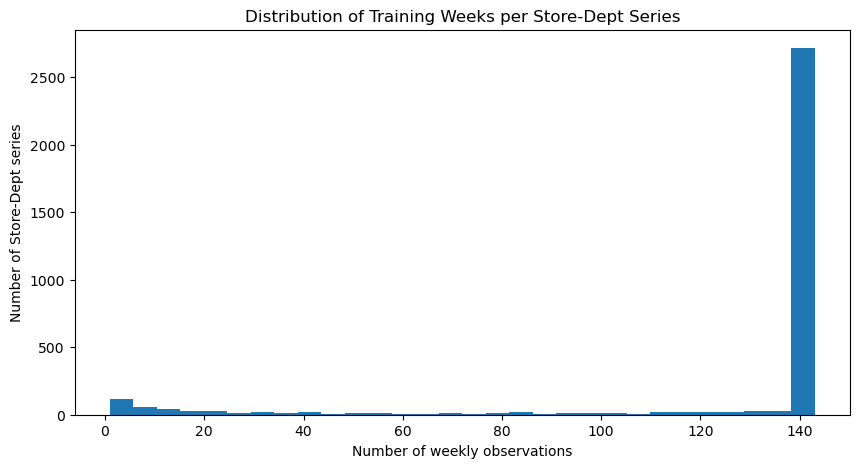

In [19]:
plt.figure(figsize=(10, 5))
plt.hist(train_series_lengths["n_train_weeks"], bins=30)
plt.title("Distribution of Training Weeks per Store-Dept Series")
plt.xlabel("Number of weekly observations")
plt.ylabel("Number of Store-Dept series")
plt.show()

In [ ]:
# count complete (143, 39) and incomplete store-dept series in train and test 

complete_train_series = (train_series_lengths["n_train_weeks"] == train["Date"].nunique()).sum()
incomplete_train_series = (train_series_lengths["n_train_weeks"] < train["Date"].nunique()).sum()

complete_test_series = (test_series_lengths["n_test_weeks"] == test["Date"].nunique()).sum()
incomplete_test_series = (test_series_lengths["n_test_weeks"] < test["Date"].nunique()).sum()

series_completeness = pd.DataFrame({
    "dataset": ["train", "test"],
    "complete_series": [complete_train_series, complete_test_series],
    "incomplete_series": [incomplete_train_series, incomplete_test_series],
    "total_series": [len(train_series_lengths), len(test_series_lengths)]
})

series_completeness["complete_percent"] = (
    series_completeness["complete_series"] / series_completeness["total_series"] * 100
).round(2)

display(series_completeness)

,dataset,complete_series,incomplete_series,total_series,complete_percent
0,train,2660,671,3331,79.86
1,test,2742,427,3169,86.53


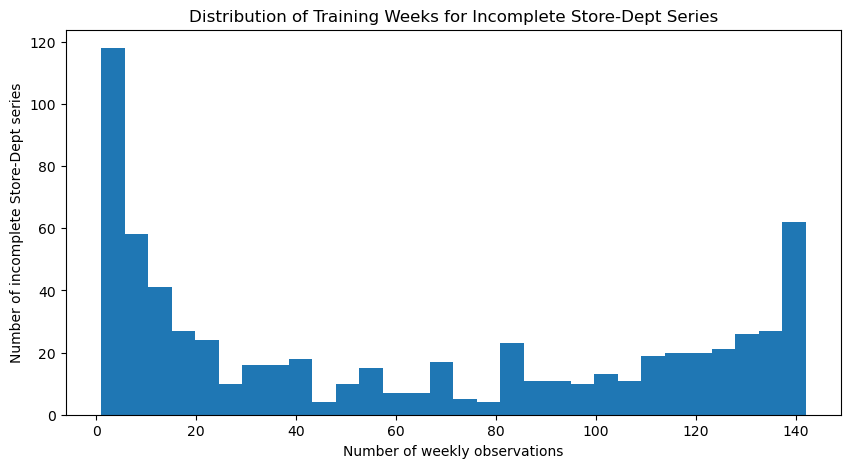

In [31]:
incomplete_train_lengths = train_series_lengths[
    train_series_lengths["n_train_weeks"] < train["Date"].nunique()
]

plt.figure(figsize=(10, 5))
plt.hist(incomplete_train_lengths["n_train_weeks"], bins=30)
plt.title("Distribution of Training Weeks for Incomplete Store-Dept Series")
plt.xlabel("Number of weekly observations")
plt.ylabel("Number of incomplete Store-Dept series")
plt.show()

# 6. Target Analysis: Weekly_Sales


In [32]:
# summary statistics for the target variable

target_summary = train["Weekly_Sales"].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
)

display(target_summary.to_frame())

,Weekly_Sales
count,421570.000000
mean,15981.258123
std,22711.183519
min,-4988.940000
1%,5.000000
5%,59.974500
25%,2079.650000
50%,7612.030000
75%,20205.852500
95%,61201.951000


In [33]:
# zero and negative sales values check

sales_quality = pd.DataFrame({
    "count": [
        (train["Weekly_Sales"] < 0).sum(),
        (train["Weekly_Sales"] == 0).sum(),
        (train["Weekly_Sales"] > 0).sum()
    ],
    "percent": [
        (train["Weekly_Sales"] < 0).mean() * 100,
        (train["Weekly_Sales"] == 0).mean() * 100,
        (train["Weekly_Sales"] > 0).mean() * 100
    ]
}, index=["negative_sales", "zero_sales", "positive_sales"])

sales_quality["percent"] = sales_quality["percent"].round(4)

display(sales_quality)

,count,percent
negative_sales,1285,0.3048
zero_sales,73,0.0173
positive_sales,420212,99.6779


negative sales can represent returns, corrections  or accounting adjustments so they can be kept for now

In [34]:
# lowest and highest Weekly_Sales rows

print("Lowest Weekly_Sales rows:")
display(train.sort_values("Weekly_Sales").head(10))

print("Highest Weekly_Sales rows:")
display(train.sort_values("Weekly_Sales", ascending=False).head(10))

Lowest Weekly_Sales rows:


,Store,Dept,Date,Weekly_Sales,IsHoliday
267730,28,6,2010-10-08,-4988.94,False
336495,35,47,2011-09-02,-3924.00,False
417801,45,47,2010-02-26,-1750.00,False
153916,16,47,2012-03-09,-1699.00,False
271300,28,32,2011-03-25,-1321.48,False
16297,2,47,2010-11-19,-1098.00,False
16295,2,47,2010-10-15,-1098.00,False
16291,2,47,2010-07-30,-1098.00,False
24830,3,32,2011-09-30,-1008.96,False
35561,4,47,2010-09-17,-898.00,False


Highest Weekly_Sales rows:


,Store,Dept,Date,Weekly_Sales,IsHoliday
95373,10,72,2010-11-26,693099.36,True
338013,35,72,2011-11-25,649770.18,True
95425,10,72,2011-11-25,630999.19,True
337961,35,72,2010-11-26,627962.93,True
135665,14,72,2010-11-26,474330.10,True
195088,20,72,2010-11-26,422306.25,True
264390,27,72,2010-11-26,420586.57,True
88428,10,7,2010-12-24,406988.63,False
95377,10,72,2010-12-24,404245.03,False
214432,22,72,2010-11-26,393705.20,True


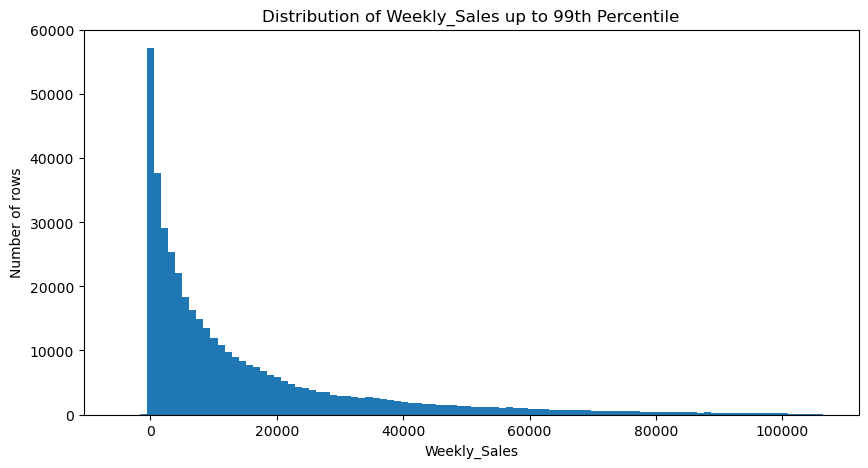

99th percentile: 106479.58599999998


In [ ]:
# clipped distribution to reduce the effect of extreme outliers and better visualization

upper_limit = train["Weekly_Sales"].quantile(0.99)

plt.figure(figsize=(10, 5))
plt.hist(train.loc[train["Weekly_Sales"] <= upper_limit, "Weekly_Sales"], bins=100)
plt.title("Distribution of Weekly_Sales up to 99th Percentile")
plt.xlabel("Weekly_Sales")
plt.ylabel("Number of rows")
plt.show()

print("99th percentile:", upper_limit)

In [47]:
near_zero_summary = pd.DataFrame({
    "condition": [
        "Weekly_Sales < 0",
        "Weekly_Sales == 0",
        "0 < Weekly_Sales <= 100",
        "0 < Weekly_Sales <= 500",
        "0 < Weekly_Sales <= 1000",
        "0 < Weekly_Sales <= 5000",
    ],
    "count": [
        (train["Weekly_Sales"] < 0).sum(),
        (train["Weekly_Sales"] == 0).sum(),
        ((train["Weekly_Sales"] > 0) & (train["Weekly_Sales"] <= 100)).sum(),
        ((train["Weekly_Sales"] > 0) & (train["Weekly_Sales"] <= 500)).sum(),
        ((train["Weekly_Sales"] > 0) & (train["Weekly_Sales"] <= 1000)).sum(),
        ((train["Weekly_Sales"] > 0) & (train["Weekly_Sales"] <= 5000)).sum(),
    ]
})

near_zero_summary["percent"] = (
    near_zero_summary["count"] / len(train) * 100
).round(3)

display(near_zero_summary)

,condition,count,percent
0,Weekly_Sales < 0,1285,0.305
1,Weekly_Sales == 0,73,0.017
2,0 < Weekly_Sales <= 100,25737,6.105
3,0 < Weekly_Sales <= 500,52070,12.351
4,0 < Weekly_Sales <= 1000,71972,17.072
5,0 < Weekly_Sales <= 5000,169316,40.163


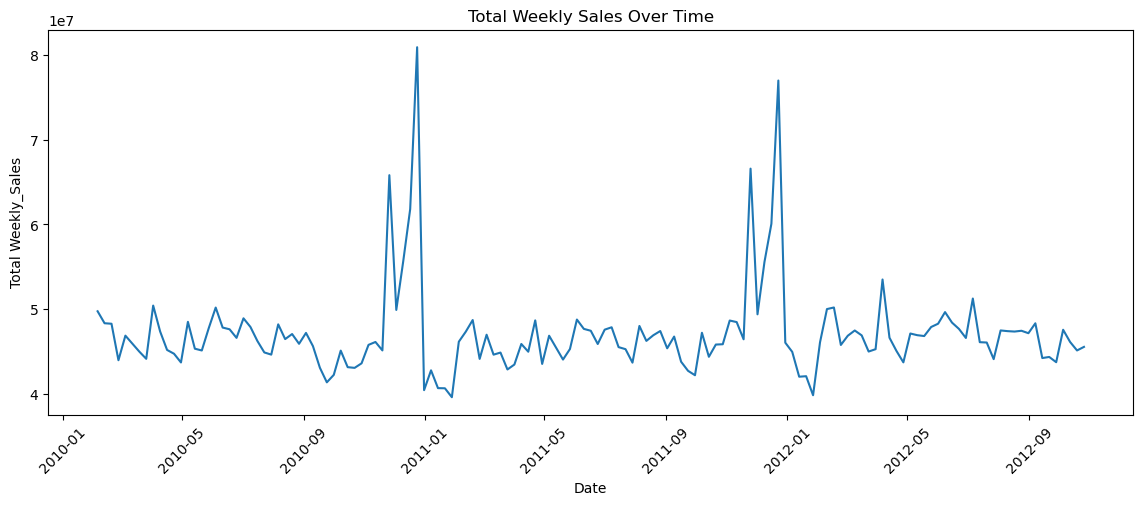

In [39]:
# total weekly sales over time

weekly_sales = (
    train.groupby("Date")["Weekly_Sales"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(14, 5))
plt.plot(weekly_sales["Date"], weekly_sales["Weekly_Sales"])
plt.title("Total Weekly Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Total Weekly_Sales")
plt.xticks(rotation=45)
plt.show()

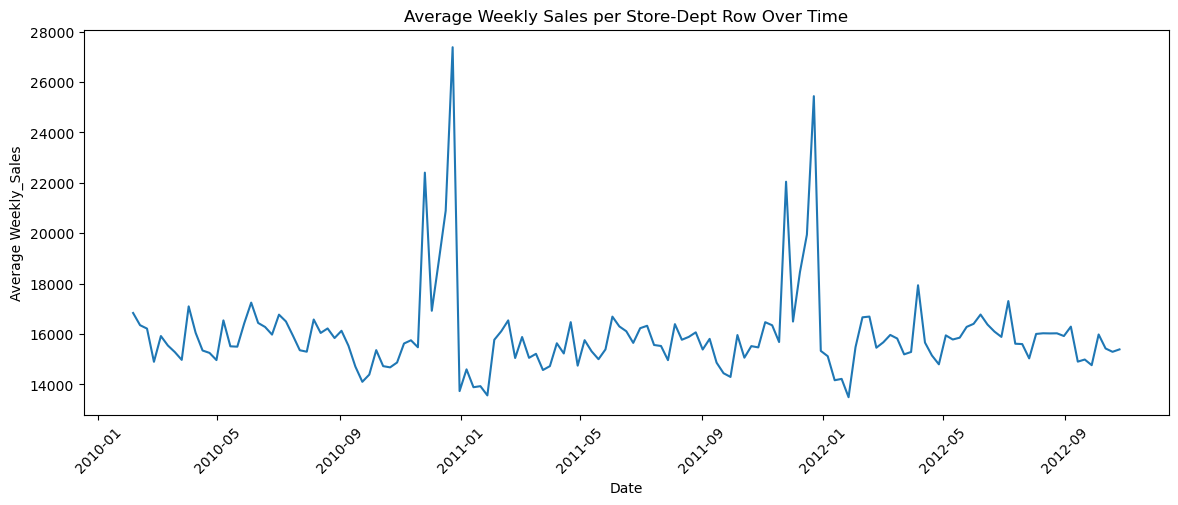

In [40]:
# average weekly sales per Store-Dept row over time

weekly_avg_sales = (
    train.groupby("Date")["Weekly_Sales"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(14, 5))
plt.plot(weekly_avg_sales["Date"], weekly_avg_sales["Weekly_Sales"])
plt.title("Average Weekly Sales per Store-Dept Row Over Time")
plt.xlabel("Date")
plt.ylabel("Average Weekly_Sales")
plt.xticks(rotation=45)
plt.show()

In [43]:
# average sales by store

store_sales = (
    train.groupby("Store")["Weekly_Sales"]
    .agg(["mean", "median", "sum", "count"])
    .sort_values("sum", ascending=False)
)

display(store_sales.head(10))

,mean,median,sum,count
Store,,,,
20,29508.301592,16249.780,3.013978e+08,10214
4,29161.210415,15116.810,2.995440e+08,10272
14,28784.851727,15208.805,2.889999e+08,10040
13,27355.136891,14018.455,2.865177e+08,10474
2,26898.070031,14333.530,2.753824e+08,10238
10,26332.303819,13941.430,2.716177e+08,10315
27,24826.984536,13625.950,2.538559e+08,10225
6,21913.243624,13637.840,2.237561e+08,10211
1,21710.543621,10289.375,2.224028e+08,10244


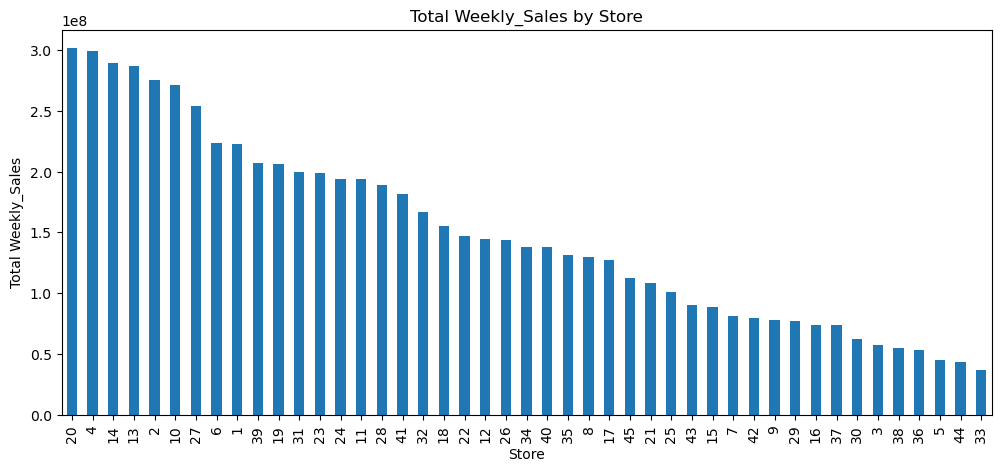

In [44]:
plt.figure(figsize=(12, 5))
store_sales["sum"].sort_values(ascending=False).plot(kind="bar")
plt.title("Total Weekly_Sales by Store")
plt.xlabel("Store")
plt.ylabel("Total Weekly_Sales")
plt.show()

In [45]:
# average sales by department

dept_sales = (
    train.groupby("Dept")["Weekly_Sales"]
    .agg(["mean", "median", "sum", "count"])
    .sort_values("sum", ascending=False)
)

display(dept_sales.head(10))
display(dept_sales.tail(10))

,mean,median,sum,count
Dept,,,,
92,75204.870531,61816.77,4.839433e+08,6435
95,69824.423080,60774.39,4.493202e+08,6435
38,61090.619568,57336.65,3.931181e+08,6435
72,50566.515417,44312.36,3.057252e+08,6046
90,45232.084488,40535.79,2.910685e+08,6435
40,44900.702727,42717.87,2.889360e+08,6435
2,43607.020113,41412.61,2.806112e+08,6435
91,33687.910758,31033.63,2.167817e+08,6435
13,30663.802634,27970.82,1.973216e+08,6435


,mean,median,sum,count
Dept,,,,
60,347.370229,279.000,2005020.96,5772
54,108.305985,58.920,516294.63,4767
99,415.487065,59.920,358149.85,862
77,328.961800,198.000,49344.27,150
45,23.211586,14.940,44937.63,1936
51,21.931729,11.000,30572.83,1394
78,7.296638,9.880,1714.71,235
39,11.123750,10.430,177.98,16
43,1.193333,0.750,14.32,12


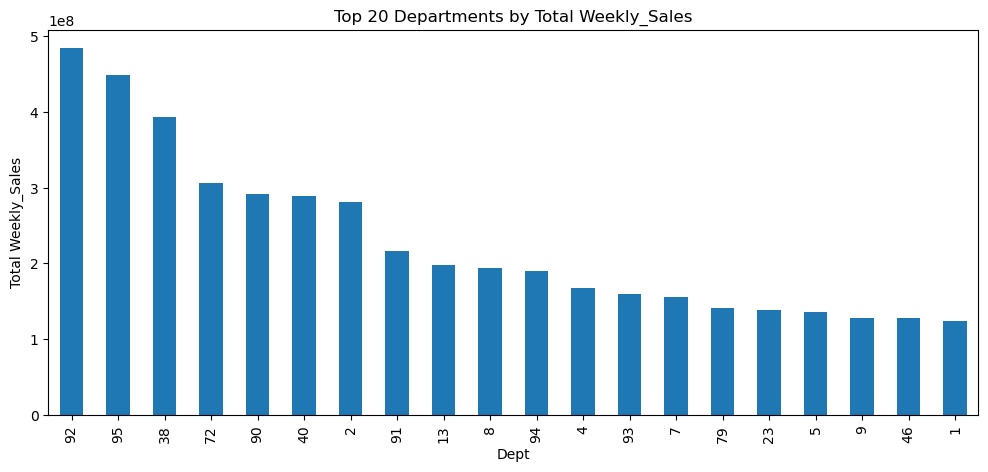

In [46]:
top_depts = dept_sales.head(20)

plt.figure(figsize=(12, 5))
top_depts["sum"].plot(kind="bar")
plt.title("Top 20 Departments by Total Weekly_Sales")
plt.xlabel("Dept")
plt.ylabel("Total Weekly_Sales")
plt.show()

### Target Analysis Observations

`Weekly_Sales` is highly skewed with most Store-Dept weekly observations having relatively moderate sales and smaller number of very large sales values. This suggests that outliers and high-volume departments/stores may affect model training.

Some observations may contain zero or negative sales but these values should not be removed automatically since negative retail sales can represent returns or accounting corrections.

Aggregating sales over time shows temporal variation and possible seasonal/holiday spikes. This supports the need for calendar features, holiday features and lag/rolling historical features.

Sales also vary across stores and departments, confirming that `Store`-`Dept` and their interaction are important predictors.

# 7. Holiday Analysis


In [48]:
# holiday frequency in train and test

holiday_summary = pd.DataFrame({
    "dataset": ["train", "test"],
    "holiday_rows": [
        train["IsHoliday"].sum(),
        test["IsHoliday"].sum()
    ],
    "non_holiday_rows": [
        (~train["IsHoliday"]).sum(),
        (~test["IsHoliday"]).sum()
    ],
    "total_rows": [
        len(train),
        len(test)
    ]
})

holiday_summary["holiday_percent"] = (
    holiday_summary["holiday_rows"] / holiday_summary["total_rows"] * 100
).round(2)

display(holiday_summary)

,dataset,holiday_rows,non_holiday_rows,total_rows,holiday_percent
0,train,29661,391909,421570,7.04
1,test,8928,106136,115064,7.76


In [49]:
# unique holiday dates in train and test

train_holiday_dates = sorted(train.loc[train["IsHoliday"], "Date"].unique())
test_holiday_dates = sorted(test.loc[test["IsHoliday"], "Date"].unique())

print("Number of unique holiday dates in train:", len(train_holiday_dates))
print("Train holiday dates:")
display(pd.Series(train_holiday_dates))

print("\nNumber of unique holiday dates in test:", len(test_holiday_dates))
print("Test holiday dates:")
display(pd.Series(test_holiday_dates))

Number of unique holiday dates in train: 10
Train holiday dates:


0   2010-02-12
1   2010-09-10
2   2010-11-26
3   2010-12-31
4   2011-02-11
5   2011-09-09
6   2011-11-25
7   2011-12-30
8   2012-02-10
9   2012-09-07
dtype: datetime64[ns]


Number of unique holiday dates in test: 3
Test holiday dates:


0   2012-11-23
1   2012-12-28
2   2013-02-08
dtype: datetime64[ns]

In [50]:
# effect of holiday weighting in Kaggle WMAE

def weight_summary(df, name):
    holiday_rows = df["IsHoliday"].sum()
    non_holiday_rows = (~df["IsHoliday"]).sum()
    
    holiday_weight = holiday_rows * 5
    non_holiday_weight = non_holiday_rows * 1
    total_weight = holiday_weight + non_holiday_weight
    
    return {
        "dataset": name,
        "holiday_rows_percent": holiday_rows / len(df) * 100,
        "holiday_weight_percent": holiday_weight / total_weight * 100
    }

wmae_weight_summary = pd.DataFrame([
    weight_summary(train, "train"),
    weight_summary(test, "test")
])

wmae_weight_summary = wmae_weight_summary.round(2)
display(wmae_weight_summary)

,dataset,holiday_rows_percent,holiday_weight_percent
0,train,7.04,27.45
1,test,7.76,29.61


In [51]:
# Weekly_Sales statistics by holiday flag

holiday_sales_stats = (
    train.groupby("IsHoliday")["Weekly_Sales"]
    .agg(["count", "mean", "median", "std", "min", "max", "sum"])
)

display(holiday_sales_stats)

,count,mean,median,std,min,max,sum
IsHoliday,,,,,,,
False,391909,15901.445069,7589.95,22330.747450,-4988.94,406988.63,6.231919e+09
True,29661,17035.823187,7947.74,27222.000409,-798.00,693099.36,5.052996e+08


In [52]:
# difference between holiday and non-holiday average sales

non_holiday_mean = train.loc[~train["IsHoliday"], "Weekly_Sales"].mean()
holiday_mean = train.loc[train["IsHoliday"], "Weekly_Sales"].mean()

print("Non-holiday mean sales:", non_holiday_mean)
print("Holiday mean sales:", holiday_mean)
print("Holiday / Non-holiday mean ratio:", holiday_mean / non_holiday_mean)

Non-holiday mean sales: 15901.445069008367
Holiday mean sales: 17035.823187350394
Holiday / Non-holiday mean ratio: 1.0713380521970868


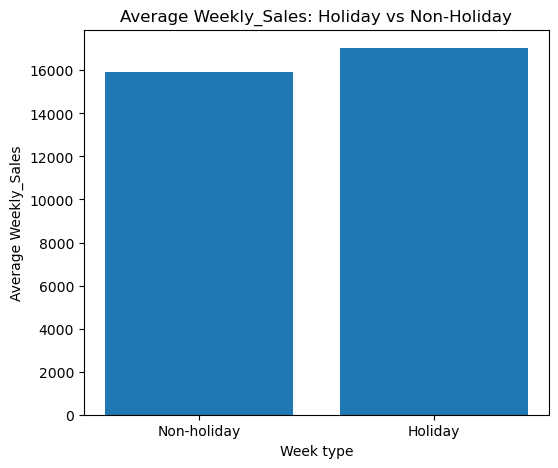

In [57]:
# average Weekly_Sales by holiday flag

holiday_means = (
    train.groupby("IsHoliday")["Weekly_Sales"]
    .mean()
    .reset_index()
)

holiday_means["IsHoliday"] = holiday_means["IsHoliday"].map({
    False: "Non-holiday",
    True: "Holiday"
})

plt.figure(figsize=(6, 5))
plt.bar(holiday_means["IsHoliday"], holiday_means["Weekly_Sales"])
plt.title("Average Weekly_Sales: Holiday vs Non-Holiday")
plt.xlabel("Week type")
plt.ylabel("Average Weekly_Sales")
plt.show()

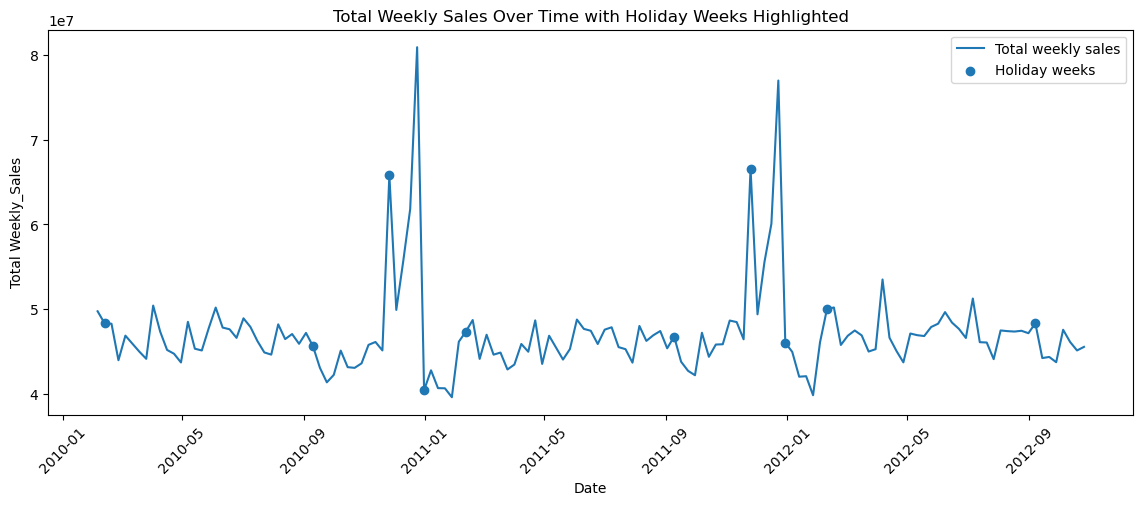

In [58]:
# total weekly sales with holiday weeks highlighted

weekly_sales = (
    train.groupby("Date")
    .agg(
        total_sales=("Weekly_Sales", "sum"),
        is_holiday=("IsHoliday", "max")
    )
    .reset_index()
)

plt.figure(figsize=(14, 5))
plt.plot(weekly_sales["Date"], weekly_sales["total_sales"], label="Total weekly sales")

holiday_weeks = weekly_sales[weekly_sales["is_holiday"]]

plt.scatter(
    holiday_weeks["Date"],
    holiday_weeks["total_sales"],
    label="Holiday weeks",
    zorder=3
)

plt.title("Total Weekly Sales Over Time with Holiday Weeks Highlighted")
plt.xlabel("Date")
plt.ylabel("Total Weekly_Sales")
plt.xticks(rotation=45)
plt.legend()
plt.show()

In [ ]:
# department-level holiday effect

dept_holiday_effect = (
    train.groupby(["Dept", "IsHoliday"])["Weekly_Sales"]
    .mean()
    .unstack()
    .rename(columns={False: "non_holiday_mean", True: "holiday_mean"})
)

dept_holiday_effect["holiday_to_nonholiday_ratio"] = (
    dept_holiday_effect["holiday_mean"] / dept_holiday_effect["non_holiday_mean"]
)

dept_counts = train.groupby("Dept").size()
dept_holiday_effect["n_rows"] = dept_counts

# filter out small/noisy departments
dept_holiday_effect_filtered = dept_holiday_effect[
    dept_holiday_effect["n_rows"] >= 1000
].dropna()

display(
    dept_holiday_effect_filtered
    .sort_values("holiday_to_nonholiday_ratio", ascending=False)
    .head(15)
)

display(
    dept_holiday_effect_filtered
    .sort_values("holiday_to_nonholiday_ratio")
    .head(15)
)

IsHoliday,non_holiday_mean,holiday_mean,holiday_to_nonholiday_ratio,n_rows
Dept,,,,
59,647.219559,1310.373333,2.024619,6106
72,47217.852117,94855.542259,2.008892,6046
6,4513.898625,7832.547844,1.735207,5986
18,6908.599161,11906.612807,1.723448,5029
55,10224.378094,17269.993274,1.689100,5596
5,20538.617153,32386.823702,1.576875,6347
14,14496.807073,19847.280267,1.369079,6435
71,5597.423250,7398.241784,1.321723,5309
48,1315.234759,1725.279683,1.311766,1742


IsHoliday,non_holiday_mean,holiday_mean,holiday_to_nonholiday_ratio,n_rows
Dept,,,,
56,4025.251337,1254.923793,0.311763,5872
16,14844.779525,6277.059578,0.422846,6435
36,2057.989427,1551.123892,0.753708,5295
12,4221.482797,3562.188750,0.843824,6409
35,2945.672718,2593.096216,0.880307,5297
85,2279.736579,2060.657106,0.903901,6055
51,22.048319,20.136235,0.913278,1394
94,33595.764865,30936.964557,0.920859,5685
60,349.153660,323.418750,0.926293,5772


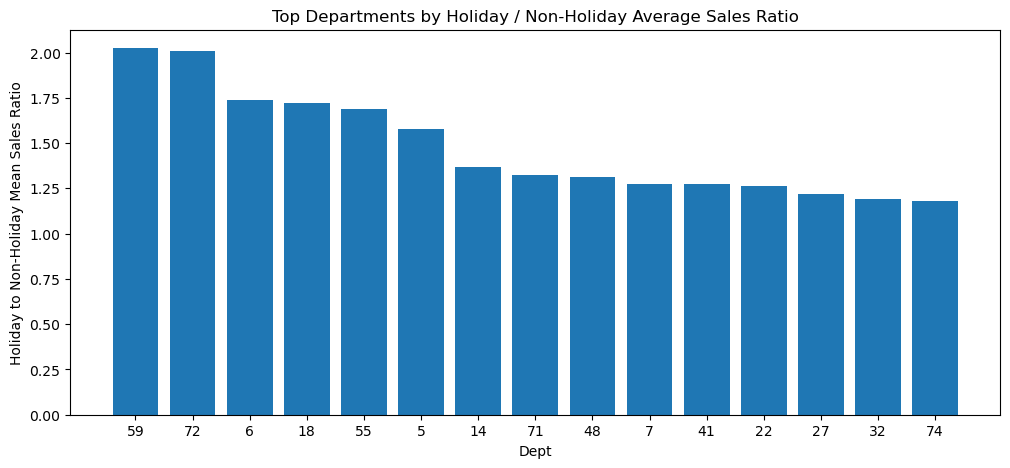

In [60]:
# top departments by holiday sales ratio

top_holiday_depts = (
    dept_holiday_effect_filtered
    .sort_values("holiday_to_nonholiday_ratio", ascending=False)
    .head(15)
)

plt.figure(figsize=(12, 5))
plt.bar(
    top_holiday_depts.index.astype(str),
    top_holiday_depts["holiday_to_nonholiday_ratio"]
)
plt.title("Top Departments by Holiday / Non-Holiday Average Sales Ratio")
plt.xlabel("Dept")
plt.ylabel("Holiday to Non-Holiday Mean Sales Ratio")
plt.show()

### Holiday Analysis Observations

Holiday rows represent a small fraction of the dataset but because Kaggle's WMAE metric weights holiday errors 5 times more heavily, they account for a larger share of the effective evaluation weight and it's important we understand them very well.

Average sales differ between holiday and non-holiday weeks and the time series plot shows some major sales spikes align with holiday weeks. This confirms `IsHoliday` should be treated as an important feature.

Time-series plot shows that holiday weeks do not perfectly capture all major sales spikes. Some of the largest peaks occur near holiday periods rather than exactly on the rows marked as `IsHoliday=True`. Therefore, the raw holiday flag is important because of the evaluation metric, but it may not be sufficient by itself. Additional calendar features such as `WeekOfYear`, `Month`, and holiday-proximity features may help models capture pre-holiday and post-holiday sales behavior.

The department level analysis shows that holiday effects are not uniform across all departments. Some departments have much stronger holiday related changes than others. This suggests that features such as `Dept - IsHoliday`, holiday-specific lag features or allowing tree models to learn interactions between `Dept`, `WeekOfYear`, and `IsHoliday` may be useful.

# 8. Missing Values and MarkDown Features

In [64]:
# missing values in features.csv

missing_features = pd.DataFrame({
    "missing_count": features.isna().sum(),
    "missing_percent": (features.isna().mean() * 100).round(2)
})

missing_features = missing_features[missing_features["missing_count"] > 0]
display(missing_features.sort_values("missing_percent", ascending=False))

,missing_count,missing_percent
MarkDown2,5269,64.33
MarkDown4,4726,57.70
MarkDown3,4577,55.89
MarkDown1,4158,50.77
MarkDown5,4140,50.55
CPI,585,7.14
Unemployment,585,7.14


In [65]:
# add period label to features based on train/test date ranges

features_missing_analysis = features.copy()

train_start = train["Date"].min()
train_end = train["Date"].max()
test_start = test["Date"].min()
test_end = test["Date"].max()

features_missing_analysis["period"] = np.select(
    [
        features_missing_analysis["Date"].between(train_start, train_end),
        features_missing_analysis["Date"].between(test_start, test_end)
    ],
    [
        "train_period",
        "test_period"
    ],
    default="other"
)

features_missing_by_period = (
    features_missing_analysis
    .groupby("period")
    .apply(lambda df: df.isna().mean() * 100)
    .round(2)
)

display(features_missing_by_period[[
    "MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5",
    "CPI", "Unemployment"
]])

C:\Users\Myvari\AppData\Local\Temp\ipykernel_23976\3374200492.py:25: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: df.isna().mean() * 100)


,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
period,,,,,,,
test_period,0.17,26.84,10.71,14.59,0.00,33.33,33.33
train_period,64.57,74.56,68.21,69.46,64.34,0.00,0.00


In [72]:
markdown_cols = ["MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5"]

# first date where each MarkDown column is non-missing

markdown_start_dates = {}

for col in markdown_cols:
    non_missing_dates = features.loc[features[col].notna(), "Date"]
    markdown_start_dates[col] = non_missing_dates.min()

markdown_start_dates = pd.Series(markdown_start_dates, name="first_non_missing_date")
display(markdown_start_dates)   

MarkDown1   2011-11-11
MarkDown2   2011-11-11
MarkDown3   2011-11-11
MarkDown4   2011-11-11
MarkDown5   2011-11-11
Name: first_non_missing_date, dtype: datetime64[ns]

In [67]:
# num of non-missing MarkDown values per date

markdown_nonmissing_by_date = (
    features
    .groupby("Date")[markdown_cols]
    .apply(lambda df: df.notna().sum())
    .reset_index()
)

display(markdown_nonmissing_by_date.head())
display(markdown_nonmissing_by_date.tail())

,Date,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5
0,2010-02-05,0,0,0,0,0
1,2010-02-12,0,0,0,0,0
2,2010-02-19,0,0,0,0,0
3,2010-02-26,0,0,0,0,0
4,2010-03-05,0,0,0,0,0


,Date,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5
177,2013-06-28,45,37,26,37,45
178,2013-07-05,45,37,43,39,45
179,2013-07-12,45,38,43,37,45
180,2013-07-19,45,38,40,38,45
181,2013-07-26,44,38,36,37,45


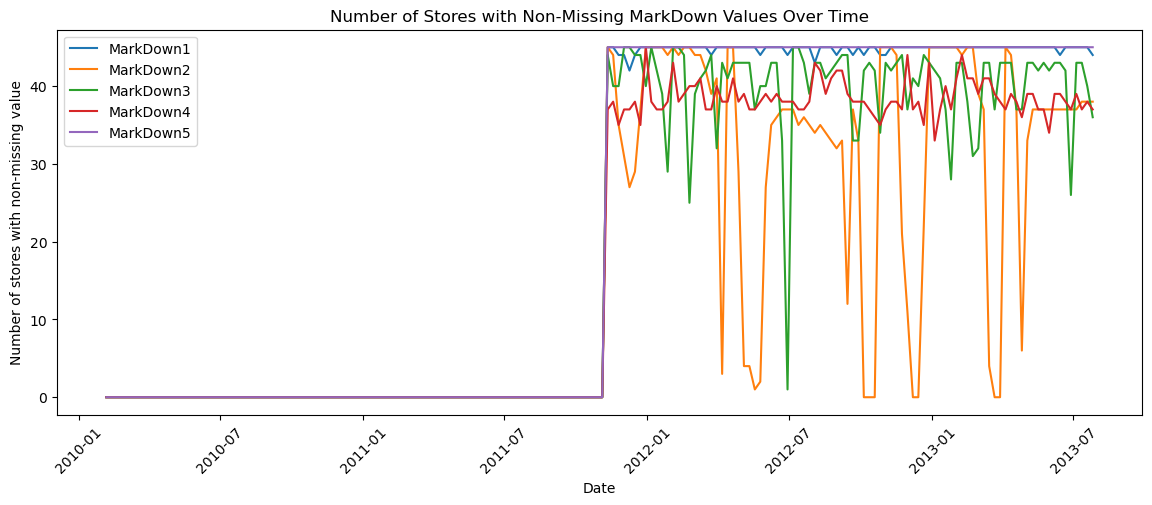

In [68]:
plt.figure(figsize=(14, 5))

for col in markdown_cols:
    plt.plot(
        markdown_nonmissing_by_date["Date"],
        markdown_nonmissing_by_date[col],
        label=col
    )

plt.title("Number of Stores with Non-Missing MarkDown Values Over Time")
plt.xlabel("Date")
plt.ylabel("Number of stores with non-missing value")
plt.xticks(rotation=45)
plt.legend()
plt.show()

In [73]:
# MarkDown statistics by holiday flag

markdown_by_holiday = (
    features
    .groupby("IsHoliday")[markdown_cols]
    .agg(["mean", "median", "count"])
)

display(markdown_by_holiday)

MarkDown1                     MarkDown2                 \
                   mean    median count          mean   median count   
IsHoliday                                                              
False       6621.591146  4725.525  3718   2549.117008   342.23  2654   
True       11896.328535  5173.960   314  11684.731423  1053.98   267   

              MarkDown3                  MarkDown4                  \
                   mean  median count         mean    median count   
IsHoliday                                                            
False        252.276325   30.91  3314  3019.268943  1236.215  3180   
True       18472.234816  188.33   299  6357.234754   528.440   284   

             MarkDown5                 
                  mean   median count  
IsHoliday                              
False      4225.809309  2755.72  3735  
True       3022.472190  2128.13   315

In [76]:
# average MarkDown values by holiday flag

markdown_means_holiday = (
    features
    .groupby("IsHoliday")[markdown_cols]
    .mean()
    .T
    .rename(columns={False: "non_holiday_mean", True: "holiday_mean"})
)

markdown_means_holiday["holiday_to_nonholiday_ratio"] = (
    markdown_means_holiday["holiday_mean"] / markdown_means_holiday["non_holiday_mean"]
)

display(markdown_means_holiday)

IsHoliday,non_holiday_mean,holiday_mean,holiday_to_nonholiday_ratio
MarkDown1,6621.591146,11896.328535,1.796597
MarkDown2,2549.117008,11684.731423,4.583835
MarkDown3,252.276325,18472.234816,73.222229
MarkDown4,3019.268943,6357.234754,2.105554
MarkDown5,4225.809309,3022.472190,0.715241


In [80]:
# temp EDA features for markdown activity

features_eda = features.copy()

features_eda["total_markdown"] = features_eda[markdown_cols].fillna(0).sum(axis=1)
features_eda["has_markdown"] = (features_eda["total_markdown"] > 0)

markdown_activity_summary = pd.DataFrame({
    "rows_with_any_markdown": [features_eda["has_markdown"].sum()],
    "rows_without_markdown": [(~features_eda["has_markdown"]).sum()],
    "percent_with_any_markdown": [(features_eda["has_markdown"].mean() * 100).round(2)]
})

display(markdown_activity_summary)

,rows_with_any_markdown,rows_without_markdown,percent_with_any_markdown
0,4048,4142,49.43


In [82]:
display(features_eda["total_markdown"].describe(
    percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
).to_frame())

,total_markdown
count,8190.000000
mean,8881.703448
std,19084.538888
min,-1692.480000
25%,0.000000
50%,0.000000
75%,11819.642500
90%,25223.276000
95%,40246.988000
99%,84864.795600


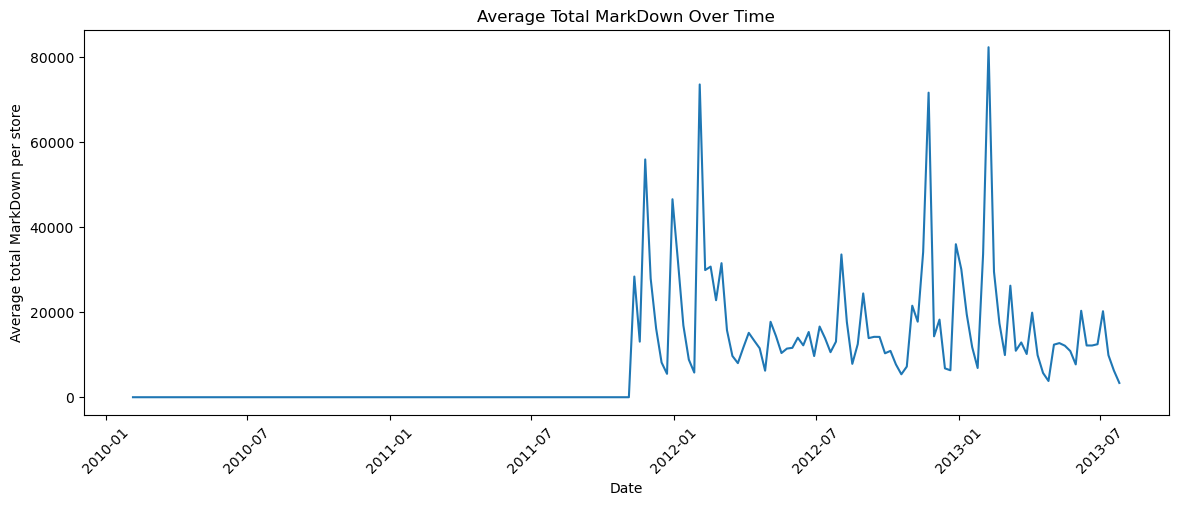

In [83]:
# average total markdown over time

total_markdown_by_date = (
    features_eda
    .groupby("Date")["total_markdown"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(14, 5))
plt.plot(total_markdown_by_date["Date"], total_markdown_by_date["total_markdown"])
plt.title("Average Total MarkDown Over Time")
plt.xlabel("Date")
plt.ylabel("Average total MarkDown per store")
plt.xticks(rotation=45)
plt.show()

In [84]:
# dates with missing CPI or Unemployment

missing_cpi_unemp = features[
    features["CPI"].isna() | features["Unemployment"].isna()
]

missing_cpi_unemp_by_date = (
    missing_cpi_unemp
    .groupby("Date")
    .agg(
        missing_rows=("Store", "count"),
        missing_cpi=("CPI", lambda x: x.isna().sum()),
        missing_unemployment=("Unemployment", lambda x: x.isna().sum())
    )
    .reset_index()
)

display(missing_cpi_unemp_by_date)

,Date,missing_rows,missing_cpi,missing_unemployment
0,2013-05-03,45,45,45
1,2013-05-10,45,45,45
2,2013-05-17,45,45,45
3,2013-05-24,45,45,45
4,2013-05-31,45,45,45
5,2013-06-07,45,45,45
6,2013-06-14,45,45,45
7,2013-06-21,45,45,45
8,2013-06-28,45,45,45
9,2013-07-05,45,45,45


13 dates are missing for all 45 stores

In [85]:
missing_cpi_unemp_by_date["period"] = np.select(
    [
        missing_cpi_unemp_by_date["Date"].between(train_start, train_end),
        missing_cpi_unemp_by_date["Date"].between(test_start, test_end)
    ],
    [
        "train_period",
        "test_period"
    ],
    default="other"
)

display(missing_cpi_unemp_by_date)

,Date,missing_rows,missing_cpi,missing_unemployment,period
0,2013-05-03,45,45,45,test_period
1,2013-05-10,45,45,45,test_period
2,2013-05-17,45,45,45,test_period
3,2013-05-24,45,45,45,test_period
4,2013-05-31,45,45,45,test_period
5,2013-06-07,45,45,45,test_period
6,2013-06-14,45,45,45,test_period
7,2013-06-21,45,45,45,test_period
8,2013-06-28,45,45,45,test_period
9,2013-07-05,45,45,45,test_period


In [86]:
# temporary merged training data for EDA

train_merged_eda = (
    train
    .merge(stores, on="Store", how="left")
    .merge(features, on=["Store", "Date", "IsHoliday"], how="left")
)

print("Original train rows:", len(train))
print("Merged train rows:", len(train_merged_eda))

assert len(train_merged_eda) == len(train)
display(train_merged_eda.head())

Original train rows: 421570
Merged train rows: 421570


,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
0,1,1,2010-02-05,24924.50,False,A,151315,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106
1,1,1,2010-02-12,46039.49,True,A,151315,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106
2,1,1,2010-02-19,41595.55,False,A,151315,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106
3,1,1,2010-02-26,19403.54,False,A,151315,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106
4,1,1,2010-03-05,21827.90,False,A,151315,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106


In [87]:
train_merged_eda["total_markdown"] = train_merged_eda[markdown_cols].fillna(0).sum(axis=1)
train_merged_eda["has_markdown"] = train_merged_eda["total_markdown"] > 0

In [88]:
markdown_sales_stats = (
    train_merged_eda
    .groupby("has_markdown")["Weekly_Sales"]
    .agg(["count", "mean", "median", "std", "sum"])
)

display(markdown_sales_stats)

,count,mean,median,std,sum
has_markdown,,,,,
False,270138,15871.522017,7654.845,22411.830633,4.287501e+09
True,151432,16177.015244,7537.870,23234.409534,2.449718e+09


In [89]:
holiday_markdown_sales = (
    train_merged_eda
    .groupby(["IsHoliday", "has_markdown"])["Weekly_Sales"]
    .agg(["count", "mean", "median"])
)

display(holiday_markdown_sales)

count          mean    median
IsHoliday has_markdown                                
False     False         252468  15816.567631  7640.720
          True          139441  16055.121800  7495.890
True      False          17670  16656.707302  7853.775
          True           11991  17594.490329  8065.360

### Missing Values and MarkDown Observations

The main missing values are in `MarkDown1`–`MarkDown5` columns. Their missingness is structural rather than random, all five MarkDown variables first appear on 2011-11-11 which explains why training period has high MarkDown missingness. In test period MarkDown values are  more available but `MarkDown2`, `MarkDown3` and `MarkDown4` still contain some missing values.

CPI and Unemployment have no missing values during the training period, but they are missing for final 13 test weeks from 2013-05-03 to 2013-07-26. Since each of these dates has 45 missing rows, missingness occurs for all stores on those dates. This means final inference pipeline must handle missing CPI and Unemployment values in the raw test set. A time-aware strategy such as forward-filling within each store is a reasonable candidate.

After filling missing MarkDown values with 0 for EDA, about 49.43% of store-date rows have at least one nonzero MarkDown value. The `total_markdown` variable is highly skewed: the median is 0, while the 99th percentile is 84,864.80 and the maximum is 783,529.45.

Rows with markdown activity have only slightly higher average sales overall. Difference is larger during holiday weeks, holiday rows with markdowns have higher average sales than holiday rows without markdowns. This suggests that MarkDown variables are likely more useful through interactions with holiday, calendar, store and department features instead of simple standalone predictors.

# 9. Train/Test Comparison

In [90]:
# merge train and test with store metadata and external features

train_merged = (
    train
    .merge(stores, on="Store", how="left")
    .merge(features, on=["Store", "Date", "IsHoliday"], how="left")
)

test_merged = (
    test
    .merge(stores, on="Store", how="left")
    .merge(features, on=["Store", "Date", "IsHoliday"], how="left")
)

print("Original train rows:", len(train))
print("Merged train rows:", len(train_merged))
print("Original test rows:", len(test))
print("Merged test rows:", len(test_merged))

assert len(train_merged) == len(train)
assert len(test_merged) == len(test)

display(train_merged.head())
display(test_merged.head())

Original train rows: 421570
Merged train rows: 421570
Original test rows: 115064
Merged test rows: 115064


,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
0,1,1,2010-02-05,24924.50,False,A,151315,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106
1,1,1,2010-02-12,46039.49,True,A,151315,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106
2,1,1,2010-02-19,41595.55,False,A,151315,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106
3,1,1,2010-02-26,19403.54,False,A,151315,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106
4,1,1,2010-03-05,21827.90,False,A,151315,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106


,Store,Dept,Date,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
0,1,1,2012-11-02,False,A,151315,55.32,3.386,6766.44,5147.70,50.82,3639.90,2737.42,223.462779,6.573
1,1,1,2012-11-09,False,A,151315,61.24,3.314,11421.32,3370.89,40.28,4646.79,6154.16,223.481307,6.573
2,1,1,2012-11-16,False,A,151315,52.92,3.252,9696.28,292.10,103.78,1133.15,6612.69,223.512911,6.573
3,1,1,2012-11-23,True,A,151315,56.23,3.211,883.59,4.17,74910.32,209.91,303.32,223.561947,6.573
4,1,1,2012-11-30,False,A,151315,52.34,3.207,2460.03,NaN,3838.35,150.57,6966.34,223.610984,6.573


In [91]:
# basic train/test comparison

train_test_basic = pd.DataFrame({
    "dataset": ["train", "test"],
    "rows": [len(train), len(test)],
    "unique_dates": [train["Date"].nunique(), test["Date"].nunique()],
    "min_date": [train["Date"].min(), test["Date"].min()],
    "max_date": [train["Date"].max(), test["Date"].max()],
    "unique_stores": [train["Store"].nunique(), test["Store"].nunique()],
    "unique_departments": [train["Dept"].nunique(), test["Dept"].nunique()],
    "unique_store_dept_pairs": [
        train[["Store", "Dept"]].drop_duplicates().shape[0],
        test[["Store", "Dept"]].drop_duplicates().shape[0]
    ],
    "holiday_percent": [
        train["IsHoliday"].mean() * 100,
        test["IsHoliday"].mean() * 100
    ]
})

train_test_basic["holiday_percent"] = train_test_basic["holiday_percent"].round(2)

display(train_test_basic)

,dataset,rows,unique_dates,min_date,max_date,unique_stores,unique_departments,unique_store_dept_pairs,holiday_percent
0,train,421570,143,2010-02-05,2012-10-26,45,81,3331,7.04
1,test,115064,39,2012-11-02,2013-07-26,45,81,3169,7.76


In [92]:
# Store, department, and Store-Dept overlap between train and test (repeated but for clarity)

train_stores = set(train["Store"].unique())
test_stores = set(test["Store"].unique())

train_depts = set(train["Dept"].unique())
test_depts = set(test["Dept"].unique())

train_series = set(map(tuple, train[["Store", "Dept"]].drop_duplicates().values))
test_series = set(map(tuple, test[["Store", "Dept"]].drop_duplicates().values))

overlap_summary = pd.DataFrame({
    "item": [
        "stores",
        "departments",
        "Store-Dept pairs"
    ],
    "train_count": [
        len(train_stores),
        len(train_depts),
        len(train_series)
    ],
    "test_count": [
        len(test_stores),
        len(test_depts),
        len(test_series)
    ],
    "in_both": [
        len(train_stores & test_stores),
        len(train_depts & test_depts),
        len(train_series & test_series)
    ],
    "test_only": [
        len(test_stores - train_stores),
        len(test_depts - train_depts),
        len(test_series - train_series)
    ],
    "train_only": [
        len(train_stores - test_stores),
        len(train_depts - test_depts),
        len(train_series - test_series)
    ]
})

display(overlap_summary)

test_only_series = sorted(test_series - train_series)
display(pd.DataFrame(test_only_series, columns=["Store", "Dept"]))

,item,train_count,test_count,in_both,test_only,train_only
0,stores,45,45,45,0,0
1,departments,81,81,81,0,0
2,Store-Dept pairs,3331,3169,3158,11,173


,Store,Dept
0,5,99
1,9,99
2,10,99
3,18,43
4,24,43
5,25,99
6,34,39
7,36,30
8,37,29
9,42,30


,train_rows_per_date
count,143.000000
mean,2948.041958
std,24.815906
min,2896.000000
25%,2931.500000
50%,2950.000000
75%,2961.000000
max,3027.000000


,test_rows_per_date
count,39.000000
mean,2950.358974
std,20.608490
min,2909.000000
25%,2937.500000
50%,2946.000000
75%,2960.500000
max,3002.000000


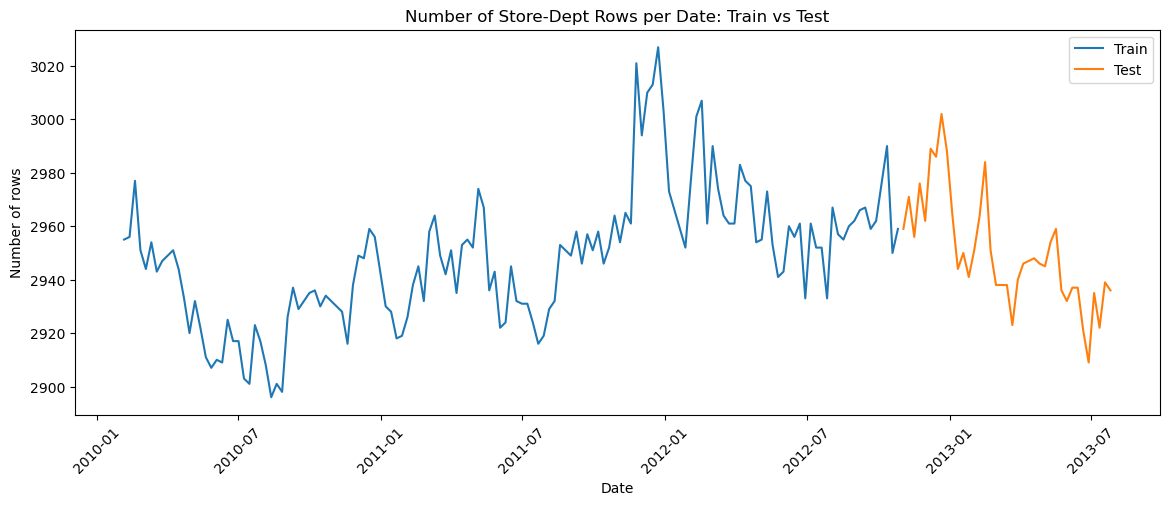

In [97]:
# number of Store-Dept rows per date in train and test

train_rows_by_date = (
    train.groupby("Date")
    .size()
    .reset_index(name="n_rows")
)

test_rows_by_date = (
    test.groupby("Date")
    .size()
    .reset_index(name="n_rows")
)

display(train_rows_by_date["n_rows"].describe().to_frame("train_rows_per_date"))
display(test_rows_by_date["n_rows"].describe().to_frame("test_rows_per_date"))

plt.figure(figsize=(14, 5))
plt.plot(train_rows_by_date["Date"], train_rows_by_date["n_rows"], label="Train")
plt.plot(test_rows_by_date["Date"], test_rows_by_date["n_rows"], label="Test")
plt.title("Number of Store-Dept Rows per Date: Train vs Test")
plt.xlabel("Date")
plt.ylabel("Number of rows")
plt.xticks(rotation=45)
plt.legend()
plt.show()

In [100]:
# store Type distribution in train and test rows

type_distribution = pd.DataFrame({
    "train_percent": train_merged["Type"].value_counts(normalize=True) * 100,
    "test_percent": test_merged["Type"].value_counts(normalize=True) * 100
}).round(2)

display(type_distribution)

,train_percent,test_percent
Type,,
A,51.11,51.03
B,38.78,38.67
C,10.10,10.30


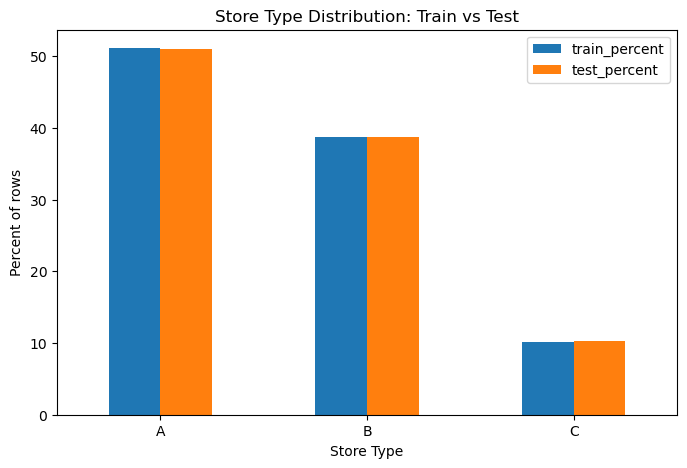

In [101]:
type_distribution.plot(kind="bar", figsize=(8, 5))
plt.title("Store Type Distribution: Train vs Test")
plt.xlabel("Store Type")
plt.ylabel("Percent of rows")
plt.xticks(rotation=0)
plt.show()

In [106]:
# store Size distribution in train and test rows

size_summary = pd.DataFrame({
    "train": train_merged["Size"].describe(),
    "test": test_merged["Size"].describe()
})

display(size_summary)

,train,test
count,421570.000000,115064.000000
mean,136727.915739,136497.688921
std,60980.583328,61106.926438
min,34875.000000,34875.000000
25%,93638.000000,93638.000000
50%,140167.000000,140167.000000
75%,202505.000000,202505.000000
max,219622.000000,219622.000000


In [102]:
external_cols = [
    "Temperature",
    "Fuel_Price",
    "CPI",
    "Unemployment",
    "MarkDown1",
    "MarkDown2",
    "MarkDown3",
    "MarkDown4",
    "MarkDown5"
]

comparison_rows = []

for col in external_cols:
    comparison_rows.append({
        "feature": col,
        "train_missing_percent": train_merged[col].isna().mean() * 100,
        "test_missing_percent": test_merged[col].isna().mean() * 100,
        "train_mean": train_merged[col].mean(),
        "test_mean": test_merged[col].mean(),
        "train_median": train_merged[col].median(),
        "test_median": test_merged[col].median()
    })

external_comparison = pd.DataFrame(comparison_rows)
external_comparison = external_comparison.round(2)

display(external_comparison)

,feature,train_missing_percent,test_missing_percent,train_mean,test_mean,train_median,test_median
0,Temperature,0.00,0.00,60.09,53.94,62.09,54.47
1,Fuel_Price,0.00,0.00,3.36,3.58,3.45,3.61
2,CPI,0.00,33.17,171.20,176.96,182.32,192.30
3,Unemployment,0.00,33.17,7.96,6.87,7.87,6.81
4,MarkDown1,64.26,0.13,7246.42,7689.22,5347.45,4842.29
5,MarkDown2,73.61,24.88,3334.63,3734.05,192.00,742.59
6,MarkDown3,67.48,8.54,1439.42,2403.09,24.60,78.26
7,MarkDown4,67.98,11.20,3383.17,3356.22,1481.31,840.94
8,MarkDown5,64.08,0.00,4628.98,3922.68,3359.45,2390.43


### Train/Test Comparison Observations

The train and test sets have a similar structural setup. Both contain the same 45 stores and 81 departments, and the percentage of holiday rows is similar: 7.04% in train and 7.76% in test.

At the exact `(Store, Dept)` level, there are 3158 Store-Dept pairs shared between train and test. Test set contains 11 Store-Dept pairs that do not appear in training set while 173 training pairs do not appear in test. This means that features based on exact Store-Dept history like Store-Dept averages, lag features and rolling statistics will need fallback handling for unseen test pairs.

The number of Store-Dept rows per week is stable between train and test. Train has average of about 2948 rows per date while test has about 2950 rows per date. This suggests that the weekly prediction structure is broadly consistent.

Store metadata is also stable. Store type distribution is nearly identical between train and test, and store size summary statistics are almost unchanged. This is expected because the same stores appear in both periods.

The main differences are in time-dependent external features. Test has lower average temperature and higher average fuel price than train. CPI and Unemployment are fully available in train but missing for 1/3 of test rows, corresponding to the final 13 test weeks. MarkDown missingness is lower in test than in train because MarkDown variables only start appearing from 2011-11-11. These differences confirm that preprocessing must handle future period missing values and that validation should be time-based.

# 10. EDA Summary and Modeling Implications

The dataset is a weekly panel forecasting problem. Each row represents sales for a specific `(Store, Dept, Date)` combination, and each `(Store, Dept)` pair can be treated as individual time series. The training period contains 143 weekly dates while the test period contains the following 39 future weeks. Pointing that validation should be time-based rather than randomly shuffled.

Store and department identifiers are important because sales vary strongly across Store-Dept combinations. Most Store-Dept series are complete but some are sparse and 11 exact Store-Dept pairs appear only in the test set. This means lag, rolling, and historical-average features will need fallback handling for sparse or unseen combinations.

`Weekly_Sales` is highly skewed with many low-sales rows and a smaller number of very large sales values. Some rows also contain zero or negative sales, most likely representing returns or corrections. These values should not be removed automatically but skewed target distribution should be considered when evaluating model errors.

Holiday weeks are important because Kaggle's WMAE metric weighs holiday errors 5 times more heavily than non-holiday errors. It's notable that the largest sales spikes do not always occur exactly on `IsHoliday=True` dates, suggesting that calendar features such as `WeekOfYear`, `Month` and holiday-proximity features may be useful in addition to the raw holiday flag.

Main missingness issue is in the external features. MarkDown values are structurally missing before 2011-11-11 and are much more available in the test period. CPI and Unemployment are available in train but missing for the final 13 test weeks so final inference pipeline must handle these missing values likely with a time-aware strategy such as forward-filling within each store.

Based on the EDA, the first shared feature set should include Store, Dept, store Type and Size, calendar features, IsHoliday, external variables, MarkDown handling features, and later lag/rolling historical sales features. Tree-based models can use these as tabular features while deep forecasting models may require more model-specific sequence/window representations.